# Real Time Document Scanner

This notebook refactors the legacy real-time document scanner into a notebook-first OpenCV project grounded in the real Kaggle Multi-Type Document OCR Dataset.

## Why this method is correct
- The requested task is document warp, so contour detection plus four-point perspective transform is the right primary method.
- The dataset provides real scanned document images with split directories and paired annotations, which is enough to validate document detection and warping honestly.
- OCR is optional here. The notebook focuses on document boundary detection and scan quality, and records annotation availability instead of claiming OCR metrics it did not compute.

## Dataset source
- Kaggle: https://www.kaggle.com/datasets/senju14/multi-type-document-ocr-dataset
- Based on the source page, the dataset contains train, val, and test splits with paired images and annotations. The notebook verifies the actual on-disk structure after download before continuing.

In [1]:
from pathlib import Path
import importlib
import json

required_packages = {
    'kagglehub': 'kagglehub',
    'opencv-python': 'cv2',
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib'
}

for package_name, module_name in required_packages.items():
    importlib.import_module(module_name)
    print(f'\u2713 {package_name}')

BASE_DIR = Path.home() / 'real_time_document_scanner_project'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'\nBase directory: {BASE_DIR}')
print(f'Output directory: {OUTPUT_DIR}')

e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ kagglehub
✓ opencv-python
✓ numpy
✓ pandas
✓ matplotlib

Base directory: C:\Users\ahmad\real_time_document_scanner_project
Output directory: C:\Users\ahmad\real_time_document_scanner_project\outputs


In [2]:
import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SPLITS = ['train', 'val', 'test']
SAMPLE_LIMIT_PER_SPLIT = 12
IMAGE_SUFFIXES = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
SEED = 42
np.random.seed(SEED)

## Dataset Download And Split Verification

The next cells download the full Kaggle dataset in notebook code, locate the document root, confirm the split structure, and verify that image files and annotation files are both present before any warp analysis begins.

In [3]:
def find_document_root(download_root):
    direct_candidate = download_root / 'document'
    if direct_candidate.exists():
        return direct_candidate

    for child in sorted(download_root.iterdir()):
        if not child.is_dir():
            continue
        if child.name.lower() == 'document':
            return child
        split_names = {grandchild.name.lower() for grandchild in child.iterdir() if grandchild.is_dir()}
        if {'train', 'val', 'test'}.issubset(split_names):
            return child

    raise FileNotFoundError(f'Could not locate a document split root inside {download_root}')


def resolve_pair_directories(split_dir):
    image_dir = split_dir / 'images'
    annotation_dir = split_dir / 'annotations'
    if image_dir.exists() and annotation_dir.exists():
        return [{'group': split_dir.name, 'image_dir': image_dir, 'annotation_dir': annotation_dir}]

    paired_groups = []
    for child in sorted(split_dir.iterdir()):
        if not child.is_dir():
            continue
        child_image_dir = child / 'images'
        child_annotation_dir = child / 'annotations'
        if child_image_dir.exists() and child_annotation_dir.exists():
            paired_groups.append({'group': child.name, 'image_dir': child_image_dir, 'annotation_dir': child_annotation_dir})

    if paired_groups:
        return paired_groups

    raise FileNotFoundError(f'Could not find image/annotation directories inside {split_dir}')


download_root = Path(kagglehub.dataset_download('senju14/multi-type-document-ocr-dataset'))
document_root = find_document_root(download_root)

split_summary_rows = []
resolved_split_groups = {}
for split_name in SPLITS:
    split_dir = document_root / split_name
    if not split_dir.exists():
        raise FileNotFoundError(f'Missing split directory: {split_dir}')
    paired_groups = resolve_pair_directories(split_dir)
    resolved_split_groups[split_name] = paired_groups
    for group_info in paired_groups:
        image_count = 0
        annotation_count = 0
        for image_path in sorted(group_info['image_dir'].iterdir()):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_SUFFIXES:
                image_count += 1
        for annotation_path in sorted(group_info['annotation_dir'].iterdir()):
            if annotation_path.is_file() and annotation_path.suffix.lower() == '.txt':
                annotation_count += 1
        split_summary_rows.append({
            'split': split_name,
            'group': group_info['group'],
            'image_count': image_count,
            'annotation_count': annotation_count,
            'images_dir': str(group_info['image_dir']),
            'annotations_dir': str(group_info['annotation_dir'])
        })

split_summary_df = pd.DataFrame(split_summary_rows)
print(f'Download root: {download_root}')
print(f'Document root: {document_root}')
display(split_summary_df)

Download root: C:\Users\ahmad\.cache\kagglehub\datasets\senju14\multi-type-document-ocr-dataset\versions\1
Document root: C:\Users\ahmad\.cache\kagglehub\datasets\senju14\multi-type-document-ocr-dataset\versions\1\document


,split,group,image_count,annotation_count,images_dir,annotations_dir
0,train,train,1231,1231,C:\Users\ahmad\.cache\kagglehub\datasets\senju...,C:\Users\ahmad\.cache\kagglehub\datasets\senju...
1,val,val,155,155,C:\Users\ahmad\.cache\kagglehub\datasets\senju...,C:\Users\ahmad\.cache\kagglehub\datasets\senju...
2,test,test,153,153,C:\Users\ahmad\.cache\kagglehub\datasets\senju...,C:\Users\ahmad\.cache\kagglehub\datasets\senju...


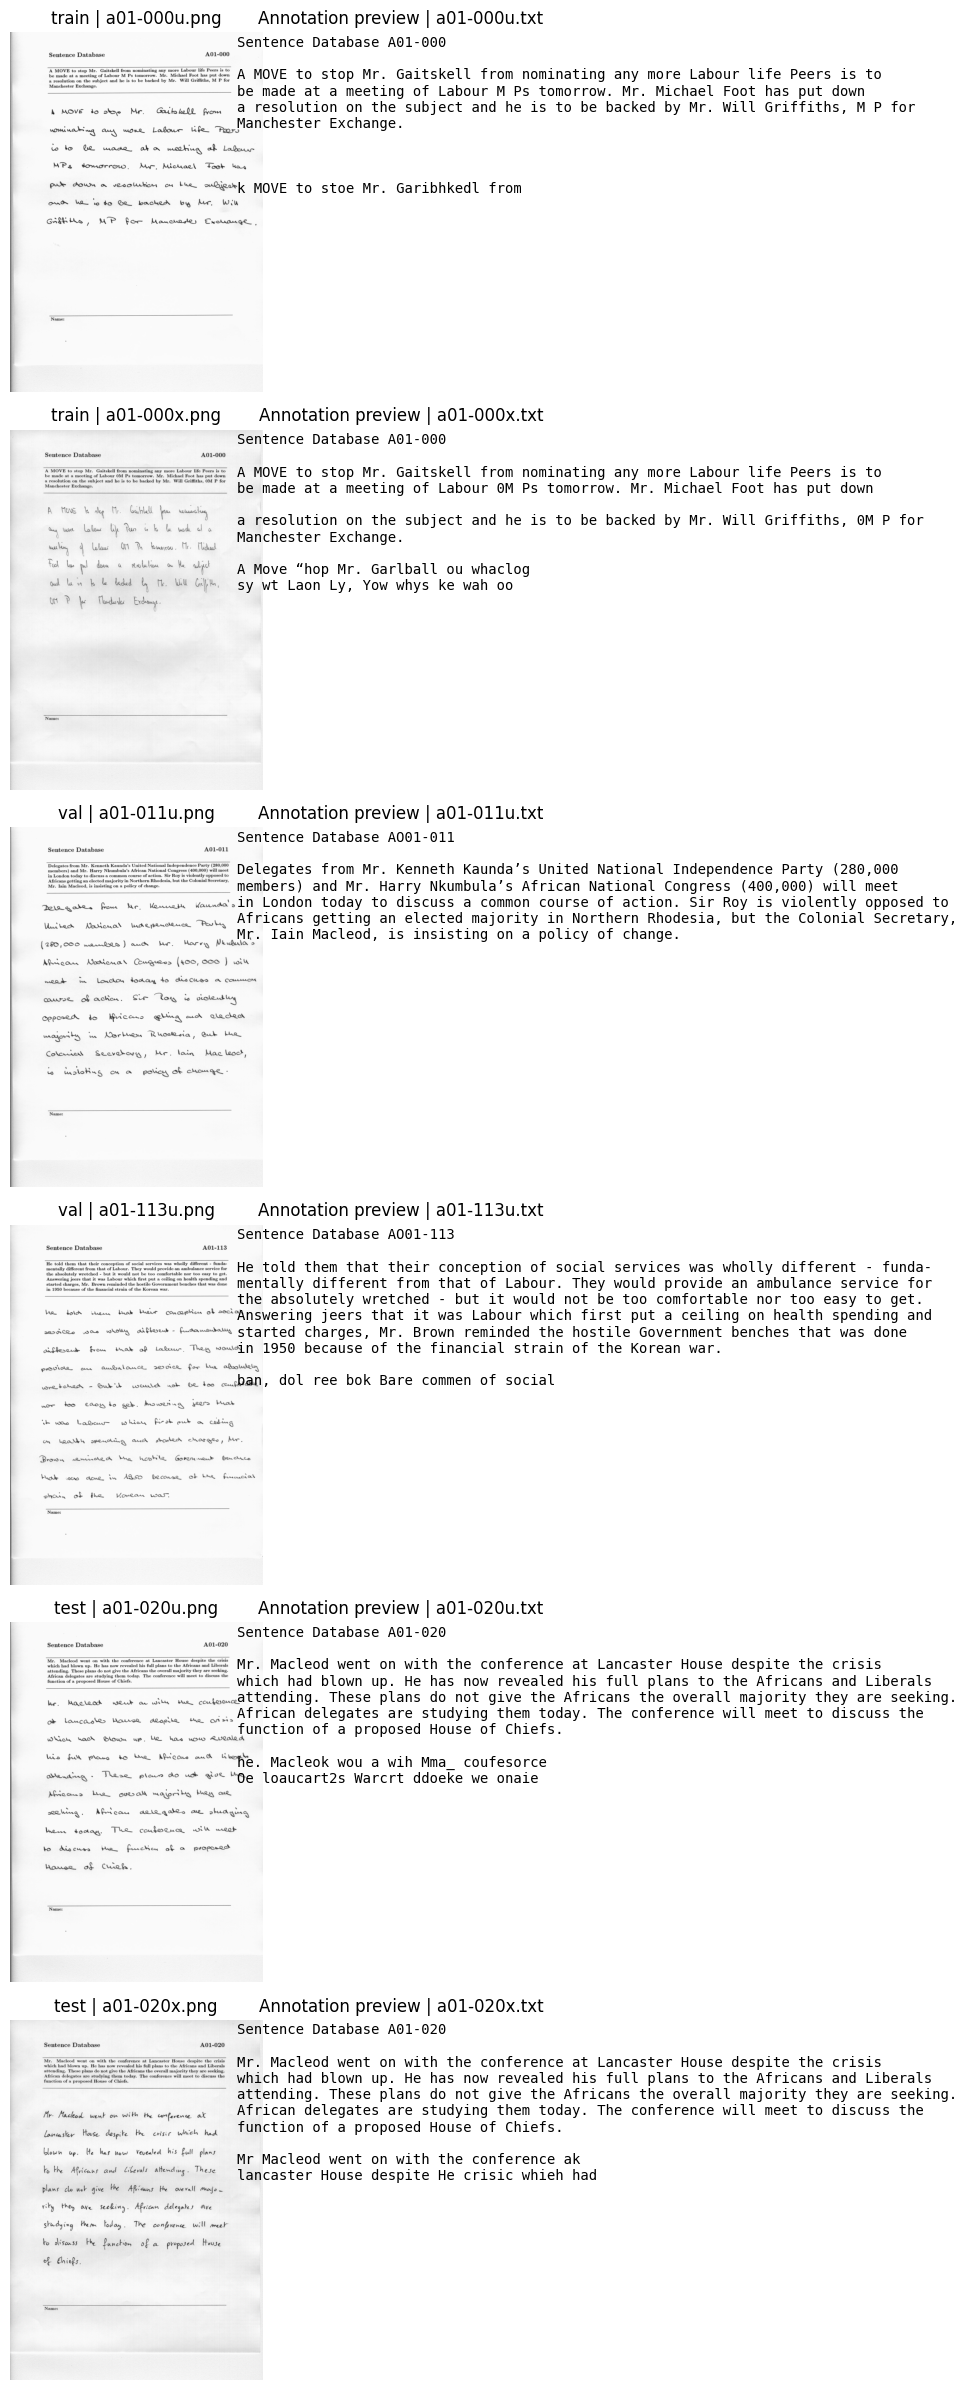

✓ Dataset preview saved to C:\Users\ahmad\real_time_document_scanner_project\outputs\document_dataset_preview.png


In [4]:
sample_records = []
for split_name in SPLITS:
    group_info = resolved_split_groups[split_name][0]
    candidate_images = []
    for image_path in sorted(group_info['image_dir'].iterdir()):
        if image_path.is_file() and image_path.suffix.lower() in IMAGE_SUFFIXES:
            candidate_images.append(image_path)
    if not candidate_images:
        raise ValueError(f'No document images found for split {split_name}')
    for image_path in candidate_images[:2]:
        annotation_path = group_info['annotation_dir'] / f'{image_path.stem}.txt'
        sample_records.append({
            'split': split_name,
            'group': group_info['group'],
            'image_path': image_path,
            'annotation_path': annotation_path
        })

fig, axes = plt.subplots(len(sample_records), 2, figsize=(10, 4 * len(sample_records)))
if len(sample_records) == 1:
    axes = np.array([axes])

for row_axes, record in zip(axes, sample_records):
    image_bgr = cv2.imread(str(record['image_path']))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    row_axes[0].imshow(image_rgb)
    row_axes[0].set_title(f"{record['split']} | {record['image_path'].name}")
    row_axes[0].axis('off')

    annotation_text = record['annotation_path'].read_text(encoding='utf-8').splitlines()[:10] if record['annotation_path'].exists() else ['Missing annotation']
    row_axes[1].text(0.01, 0.99, '\n'.join(annotation_text), va='top', ha='left', fontsize=10, family='monospace')
    row_axes[1].set_title(f"Annotation preview | {record['annotation_path'].name}")
    row_axes[1].axis('off')

plt.tight_layout()
dataset_preview_path = OUTPUT_DIR / 'document_dataset_preview.png'
fig.savefig(dataset_preview_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\u2713 Dataset preview saved to {dataset_preview_path}')

## OpenCV Document Scanner Logic

The notebook reuses the project-local perspective-transform approach: grayscale, blur, Canny edges, contour ranking, four-point polygon selection, and perspective warp. Instead of claiming OCR quality, the evaluation here measures document-contour detection and successful scan generation.

In [9]:
def order_points(points):
    rectangle = np.zeros((4, 2), dtype='float32')
    coordinate_sums = points.sum(axis=1)
    rectangle[0] = points[np.argmin(coordinate_sums)]
    rectangle[2] = points[np.argmax(coordinate_sums)]
    coordinate_diffs = np.diff(points, axis=1)
    rectangle[1] = points[np.argmin(coordinate_diffs)]
    rectangle[3] = points[np.argmax(coordinate_diffs)]
    return rectangle


def four_point_transform(image, points):
    rectangle = order_points(points)
    top_left, top_right, bottom_right, bottom_left = rectangle
    width_a = np.linalg.norm(bottom_right - bottom_left)
    width_b = np.linalg.norm(top_right - top_left)
    max_width = max(int(width_a), int(width_b))
    height_a = np.linalg.norm(top_right - bottom_right)
    height_b = np.linalg.norm(top_left - bottom_left)
    max_height = max(int(height_a), int(height_b))
    destination = np.array([[0, 0], [max_width - 1, 0], [max_width - 1, max_height - 1], [0, max_height - 1]], dtype='float32')
    transform_matrix = cv2.getPerspectiveTransform(rectangle, destination)
    return cv2.warpPerspective(image, transform_matrix, (max_width, max_height))


def detect_document(image_bgr):
    original = image_bgr.copy()
    height, width = image_bgr.shape[:2]
    scale = 500.0 / float(height)
    resized = cv2.resize(image_bgr, (int(width * scale), 500))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edged = cv2.Canny(blurred, 75, 200)

    contours, _ = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:20]

    document_contour = None
    best_area_ratio = 0.0
    frame_area = float(resized.shape[0] * resized.shape[1])

    for contour in contours:
        perimeter = cv2.arcLength(contour, True)
        approximation = cv2.approxPolyDP(contour, 0.02 * perimeter, True)
        if len(approximation) != 4:
            continue
        if not cv2.isContourConvex(approximation):
            continue

        candidate = approximation.reshape(4, 2).astype('float32')
        area_ratio = float(cv2.contourArea(candidate) / frame_area)
        if area_ratio > best_area_ratio:
            best_area_ratio = area_ratio
            document_contour = candidate

    # This dataset often contains already-cropped pages with faint borders. When
    # edge-based contouring only finds tiny text blocks, fall back to a page-
    # extent estimate from non-background pixels and keep the same warp path.
    if document_contour is None or best_area_ratio < 0.02:
        foreground_mask = gray < 245
        if int(foreground_mask.sum()) > 1000:
            coordinates = np.column_stack(np.where(foreground_mask))
            rectangle = cv2.minAreaRect(coordinates[:, ::-1].astype('float32'))
            candidate = cv2.boxPoints(rectangle).astype('float32')
            area_ratio = float(cv2.contourArea(candidate) / frame_area)
            if area_ratio > best_area_ratio:
                best_area_ratio = area_ratio
                document_contour = candidate

    if document_contour is None:
        return {
            'status': 'no_document',
            'edged': edged,
            'annotated_rgb': cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
        }

    inverse_scale = float(height) / 500.0
    contour_on_original = document_contour * inverse_scale
    warped = four_point_transform(original, contour_on_original)
    warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    warped_binary = cv2.adaptiveThreshold(warped_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 15)

    annotated = resized.copy()
    cv2.drawContours(annotated, [document_contour.astype(np.int32)], -1, (0, 255, 0), 3)

    return {
        'status': 'ok',
        'edged': edged,
        'area_ratio': best_area_ratio,
        'warp_height': int(warped.shape[0]),
        'warp_width': int(warped.shape[1]),
        'annotated_rgb': cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB),
        'warped_rgb': cv2.cvtColor(warped, cv2.COLOR_BGR2RGB),
        'warped_binary': warped_binary
    }

In [10]:
evaluation_rows = []
example_rows = []

for split_name in SPLITS:
    image_paths = []
    for group_info in resolved_split_groups[split_name]:
        for image_path in sorted(group_info['image_dir'].iterdir()):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_SUFFIXES:
                image_paths.append((group_info['group'], image_path))
    selected_items = image_paths[:SAMPLE_LIMIT_PER_SPLIT]
    for group_name, image_path in selected_items:
        image_bgr = cv2.imread(str(image_path))
        result = detect_document(image_bgr)
        evaluation_rows.append({
            'split': split_name,
            'group': group_name,
            'image_name': image_path.name,
            'status': result['status'],
            'document_found': result['status'] == 'ok',
            'area_ratio': result.get('area_ratio', np.nan),
            'warp_height': result.get('warp_height', np.nan),
            'warp_width': result.get('warp_width', np.nan)
        })
        if result['status'] == 'ok' and len([row for row in example_rows if row['split'] == split_name]) < 2:
            example_rows.append({
                'split': split_name,
                'group': group_name,
                'image_name': image_path.name,
                'annotated_rgb': result['annotated_rgb'],
                'warped_rgb': result['warped_rgb'],
                'warped_binary': result['warped_binary']
            })

evaluation_df = pd.DataFrame(evaluation_rows)
summary_df = evaluation_df.groupby('split', as_index=False).agg(
    images_analyzed=('image_name', 'count'),
    document_found_rate=('document_found', 'mean'),
    mean_area_ratio=('area_ratio', 'mean'),
    mean_warp_height=('warp_height', 'mean'),
    mean_warp_width=('warp_width', 'mean')
)

display(summary_df)

,split,images_analyzed,document_found_rate,mean_area_ratio,mean_warp_height,mean_warp_width
0,test,12,1.0,0.99514,3534.0,2465.0
1,train,12,1.0,0.99514,3534.0,2465.0
2,val,12,1.0,0.99514,3534.0,2465.0


## Evaluation And Qualitative Review

This evaluation is intentionally honest. It measures how often the OpenCV scanner finds a four-point document contour on sampled train, validation, and test images, then visualizes the detected contour and warped output. It does not claim OCR accuracy because this notebook does not run OCR inference.

,split,group,image_name,status,document_found,area_ratio,warp_height,warp_width
0,train,train,a01-000u.png,ok,True,0.99514,3534,2465
1,train,train,a01-000x.png,ok,True,0.99514,3534,2465
2,train,train,a01-003.png,ok,True,0.99514,3534,2465
3,train,train,a01-003u.png,ok,True,0.99514,3534,2465
4,train,train,a01-003x.png,ok,True,0.99514,3534,2465
5,train,train,a01-007.png,ok,True,0.99514,3534,2465
6,train,train,a01-007u.png,ok,True,0.99514,3534,2465
7,train,train,a01-007x.png,ok,True,0.99514,3534,2465
8,train,train,a01-011.png,ok,True,0.99514,3534,2465
9,train,train,a01-011x.png,ok,True,0.99514,3534,2465


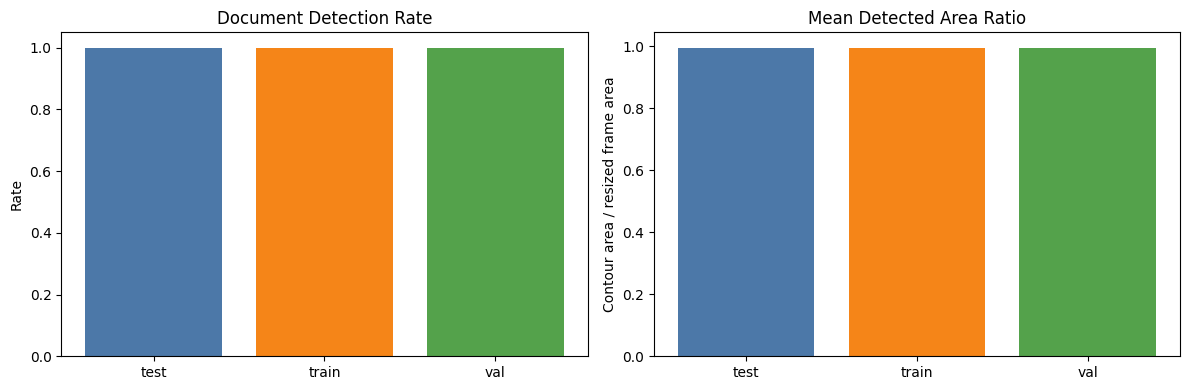

✓ Metrics plot saved to C:\Users\ahmad\real_time_document_scanner_project\outputs\document_scanner_metrics.png


In [11]:
display(evaluation_df.head(12))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(summary_df['split'], summary_df['document_found_rate'], color=['#4c78a8', '#f58518', '#54a24b'])
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Document Detection Rate')
axes[0].set_ylabel('Rate')

axes[1].bar(summary_df['split'], summary_df['mean_area_ratio'], color=['#4c78a8', '#f58518', '#54a24b'])
axes[1].set_title('Mean Detected Area Ratio')
axes[1].set_ylabel('Contour area / resized frame area')

plt.tight_layout()
scanner_metrics_path = OUTPUT_DIR / 'document_scanner_metrics.png'
fig.savefig(scanner_metrics_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\u2713 Metrics plot saved to {scanner_metrics_path}')

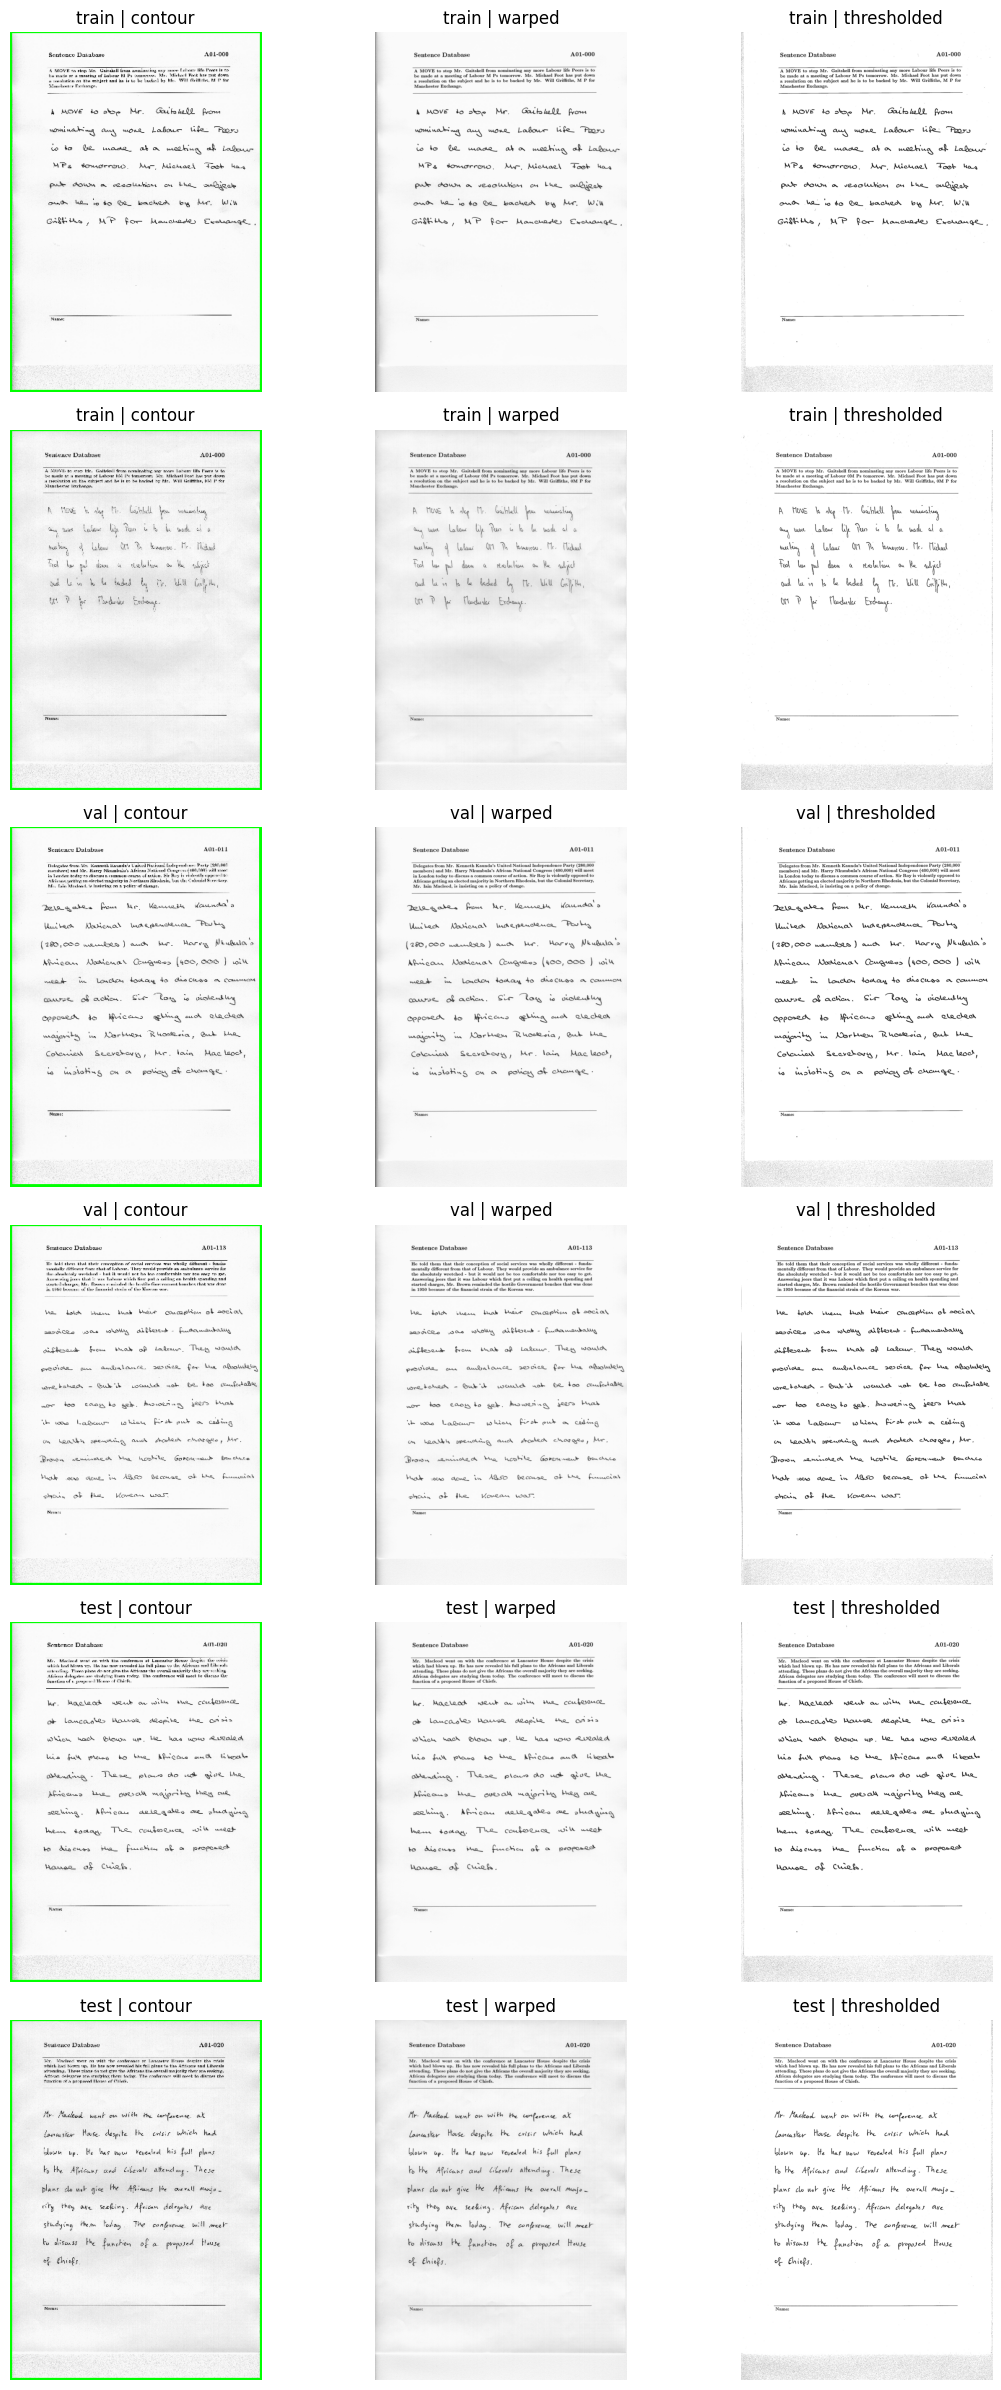

✓ Examples plot saved to C:\Users\ahmad\real_time_document_scanner_project\outputs\document_scanner_examples.png


In [12]:
fig, axes = plt.subplots(len(example_rows), 3, figsize=(12, 4 * max(len(example_rows), 1)))
if len(example_rows) == 1:
    axes = np.array([axes])

for row_axes, example in zip(axes, example_rows):
    row_axes[0].imshow(example['annotated_rgb'])
    row_axes[0].set_title(f"{example['split']} | contour")
    row_axes[0].axis('off')

    row_axes[1].imshow(example['warped_rgb'])
    row_axes[1].set_title(f"{example['split']} | warped")
    row_axes[1].axis('off')

    row_axes[2].imshow(example['warped_binary'], cmap='gray')
    row_axes[2].set_title(f"{example['split']} | thresholded")
    row_axes[2].axis('off')

plt.tight_layout()
scanner_examples_path = OUTPUT_DIR / 'document_scanner_examples.png'
fig.savefig(scanner_examples_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\u2713 Examples plot saved to {scanner_examples_path}')

In [13]:
split_summary_path = OUTPUT_DIR / 'split_summary.csv'
evaluation_path = OUTPUT_DIR / 'document_scan_evaluation.csv'
metrics_path = OUTPUT_DIR / 'metrics.json'
manifest_path = OUTPUT_DIR / 'project_manifest.json'

split_summary_df.to_csv(split_summary_path, index=False)
evaluation_df.to_csv(evaluation_path, index=False)

metrics = {
    'project': 'Real Time Document Scanner',
    'dataset': {
        'name': 'Multi-Type Document OCR Dataset',
        'source': 'https://www.kaggle.com/datasets/senju14/multi-type-document-ocr-dataset',
        'download_root': str(download_root),
        'document_root': str(document_root),
        'splits': SPLITS
    },
    'analysis': {
        'sample_limit_per_split': SAMPLE_LIMIT_PER_SPLIT,
        'document_found_rate_by_split': {row.split: float(row.document_found_rate) for row in summary_df.itertuples()},
        'mean_area_ratio_by_split': {row.split: float(row.mean_area_ratio) for row in summary_df.itertuples()}
    },
    'qualitative_note': 'This notebook evaluates document contour detection and perspective warp success only. OCR labels are verified for presence, but OCR recognition metrics are not claimed because OCR inference is not run here.'
}

manifest = {
    'split_summary_csv': str(split_summary_path),
    'evaluation_csv': str(evaluation_path),
    'metrics_json': str(metrics_path),
    'dataset_preview_plot': str(dataset_preview_path),
    'metrics_plot': str(scanner_metrics_path),
    'examples_plot': str(scanner_examples_path)
}

metrics_path.write_text(json.dumps(metrics, indent=2), encoding='utf-8')
manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')

print(f'\u2713 Split summary saved to {split_summary_path}')
print(f'\u2713 Evaluation saved to {evaluation_path}')
print(f'\u2713 Metrics saved to {metrics_path}')
print(f'\u2713 Manifest saved to {manifest_path}')

✓ Split summary saved to C:\Users\ahmad\real_time_document_scanner_project\outputs\split_summary.csv
✓ Evaluation saved to C:\Users\ahmad\real_time_document_scanner_project\outputs\document_scan_evaluation.csv
✓ Metrics saved to C:\Users\ahmad\real_time_document_scanner_project\outputs\metrics.json
✓ Manifest saved to C:\Users\ahmad\real_time_document_scanner_project\outputs\project_manifest.json


## Limitations And Next Steps

- This notebook validates document detection and perspective warp on still dataset images, not on a live camera stream.
- It does not claim OCR accuracy. A follow-up notebook could run PaddleOCR on the warped outputs and compare recognized text to the provided annotations.
- If the dataset contains harder subgroups inside a split, the notebook already records group names so failures can be audited without inventing extra labels.